<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


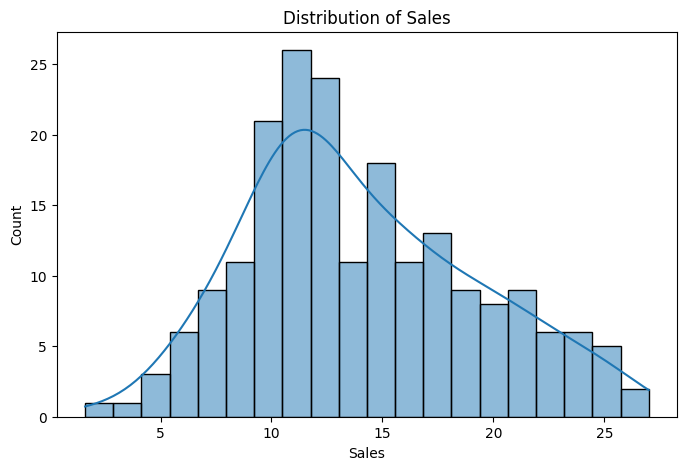

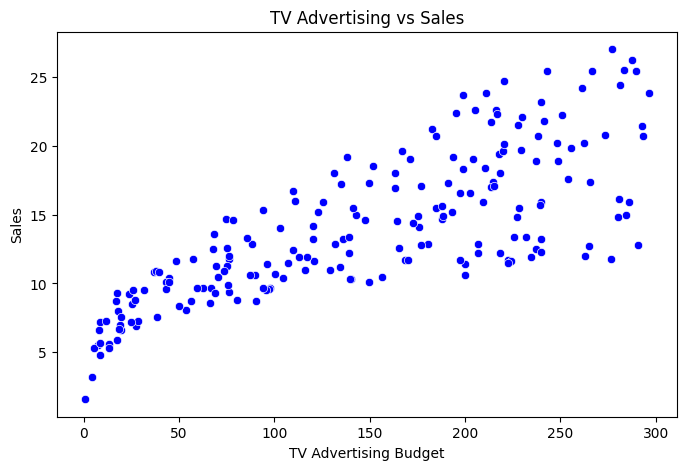

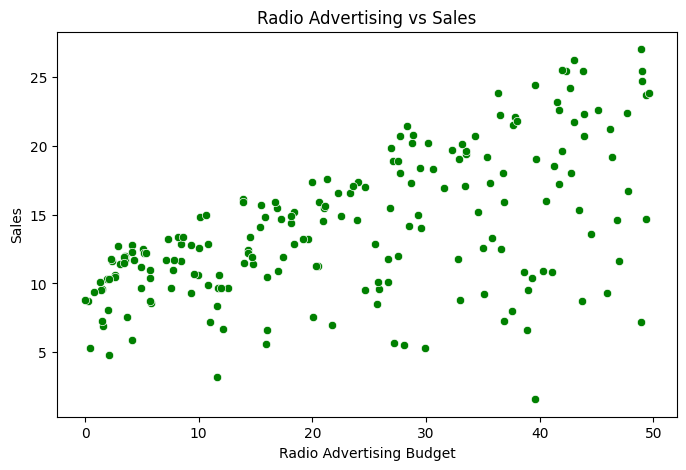

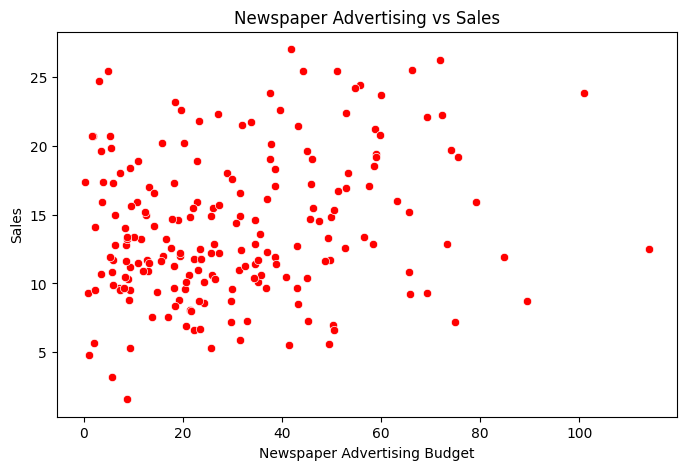

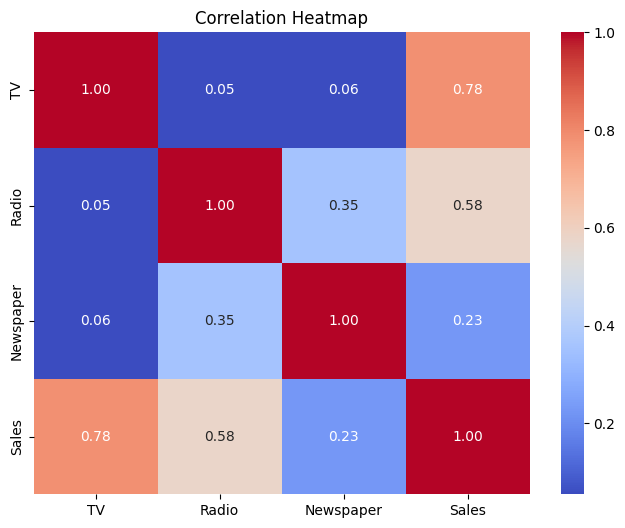

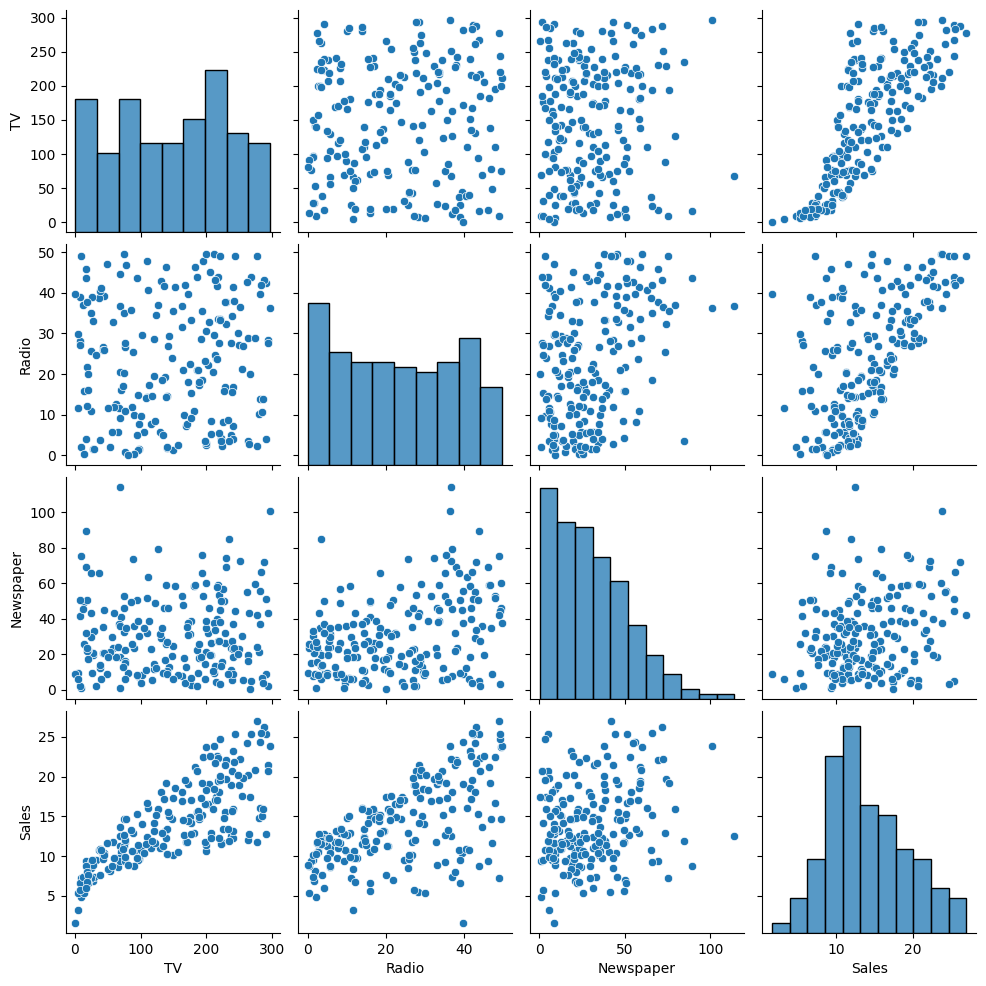

Feature Shape: (200, 3)
Target Shape: (200,)
Training Samples: 160
Testing Samples: 40
Linear Regression Model Trained Successfully!
[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]
Model Performance
-------------------------
MAE : 1.46
RMSE : 1.78
R² Score : 0.8994


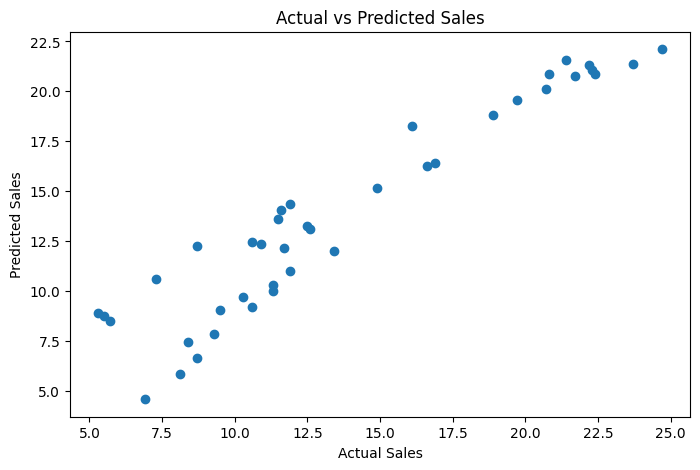

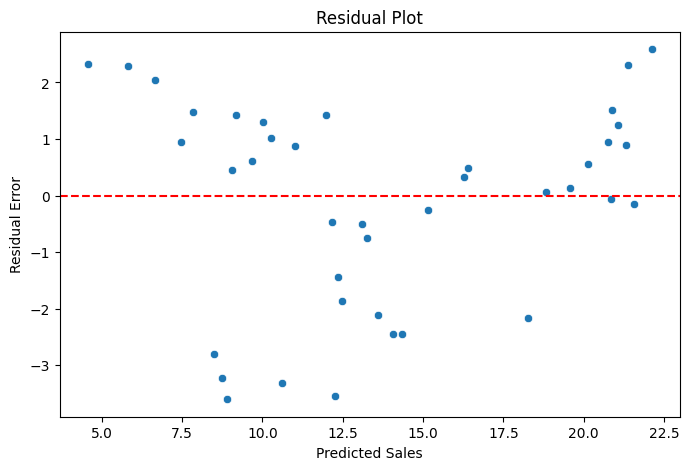

Predicted Sales: 14.47


In [21]:
# CodeAlpha Data Science Internship

# Task 4: Sales Prediction using Python


# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Load the Dataset
df = pd.read_csv("Advertising.csv")
# Display the Dataset
df.head()
# Understanding the Dataset
df.shape
df.columns
df.info()
df.describe()

# Data Cleaning
# Check missing values
df.isnull().sum()
# Check duplicate rows
df.duplicated().sum()
# Remove duplicates if present
df = df.drop_duplicates()
df.shape
df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

# Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=20, kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.show()

# TV Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='TV', y='Sales', data=df, color='blue')
plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.show()

# Radio Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Radio', y='Sales', data=df, color='green')
plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.show()

# Newspaper Advertising vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x='Newspaper', y='Sales', data=df, color='red')
plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df)
plt.show()

# Feature Selection
# Features
X = df[['TV', 'Radio', 'Newspaper']]
# Target
y = df['Sales']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# Splitting the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# Training the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

# Predicting Sales
y_pred = model.predict(X_test)
print(y_pred[:10])

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Model Performance")
print("-------------------------")
print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

# Actual Sales vs Predicted Sales
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()

# Predict Sales for New Advertising Budgets
new_data = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [20]})
prediction = model.predict(new_data)
print("Predicted Sales:", round(prediction[0],2))

